# Olympic Athlete Performance Analysis (1896–2024)

This project analyzes Olympic athlete data from 1896 to 2024.

Objectives:
- Explore Olympic participation trends
- Analyze country medal dominance
- Study athlete physical characteristics
- Identify top Olympic athletes
- Evaluate country performance efficiency
- Build a machine learning model to predict medal outcomes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("archive/olympics_athletes_dataset.csv")

df.head()

,athlete_id,athlete_name,gender,age,date_of_birth,nationality,country_name,sport,event,games_type,...,bronze_medals,country_total_gold,country_total_medals,country_first_participation,country_best_rank,is_record_holder,coach_name,height_cm,weight_kg,notes
0,ATH-00001,Svetlana Jung,Female,19,2005-12-04,AUT,Austria,Rowing,Four W,Summer,...,1,59,196,1896,18,No,Wei Ping,175.9,73.7,-
1,ATH-00002,Mary Yamamoto,Female,37,1987-07-11,MEX,Mexico,Ski Jumping,Normal Hill Team,Winter,...,5,14,72,1924,35,No,Yury Zakharevich,165.4,68.3,Olympic Debut
2,ATH-00003,Oksana Volkov,Female,37,1987-02-02,BUL,Bulgaria,Figure Skating,Women's Singles,Winter,...,1,54,224,1896,15,No,Alberto Salazar,164.2,67.2,-
3,ATH-00004,Rui Suzuki,Male,32,1992-12-08,HKG,Hong Kong,Triathlon,Men's Triathlon,Summer,...,0,3,9,1952,60,Olympic Record,Marcus O'Sullivan,190.0,76.0,First from country
4,ATH-00005,Natalya Grigoryan,Female,27,1997-11-15,SWE,Sweden,Triathlon,Men's Triathlon,Summer,...,0,200,648,1896,4,No,John Smith,175.8,60.9,Season Best


In [3]:
df = df.drop_duplicates()

df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], errors="coerce")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   athlete_id                   8500 non-null   str           
 1   athlete_name                 8500 non-null   str           
 2   gender                       8500 non-null   str           
 3   age                          8500 non-null   int64         
 4   date_of_birth                8500 non-null   datetime64[us]
 5   nationality                  8500 non-null   str           
 6   country_name                 8500 non-null   str           
 7   sport                        8500 non-null   str           
 8   event                        8500 non-null   str           
 9   games_type                   8500 non-null   str           
 10  year                         8500 non-null   int64         
 11  host_city                    8500 non-null   str      

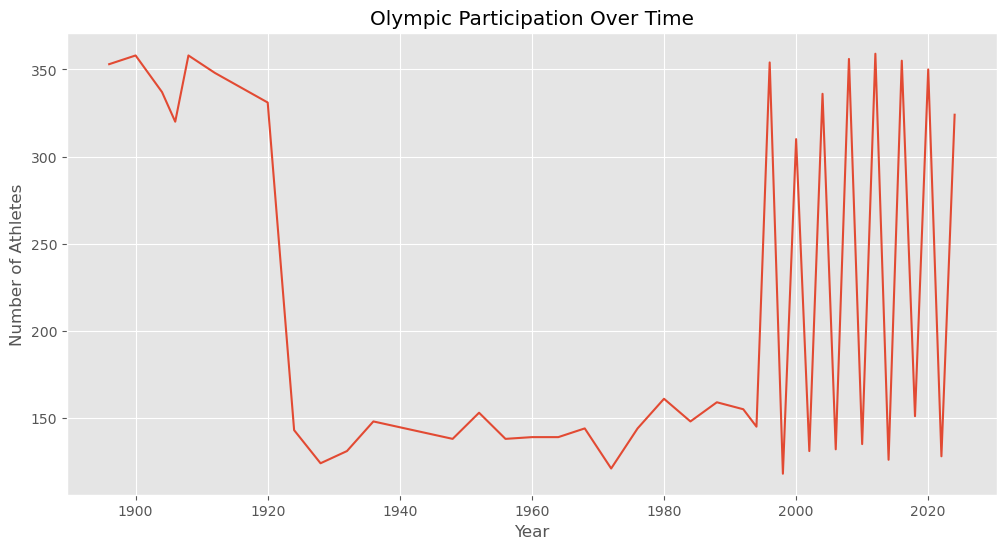

In [4]:
athletes_per_year = df.groupby("year")["athlete_id"].nunique()

plt.figure(figsize=(12,6))
plt.plot(athletes_per_year)

plt.title("Olympic Participation Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Athletes")

plt.show()

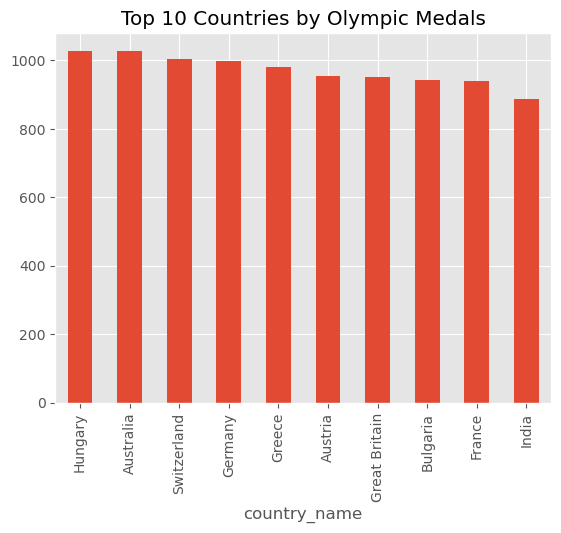

In [5]:
country_medals = df.groupby("country_name")["total_medals_won"].sum()

top_countries = country_medals.sort_values(ascending=False).head(10)

plt.figure()
top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Olympic Medals")

plt.show()

In [6]:
top_athletes = df.groupby("athlete_name")["total_medals_won"].max()

top_athletes = top_athletes.sort_values(ascending=False).head(10)

top_athletes

athlete_name
Nigar Bekele               9
Irina Thomas               9
Alexandra Amiranashvili    9
Alexei Sargsyan            9
Mark Yohannes              9
Eliud Weber                9
George Yamamoto            9
Adrien Hasanov             9
Naoto Kato                 9
Erik Thomas                9
Name: total_medals_won, dtype: int64

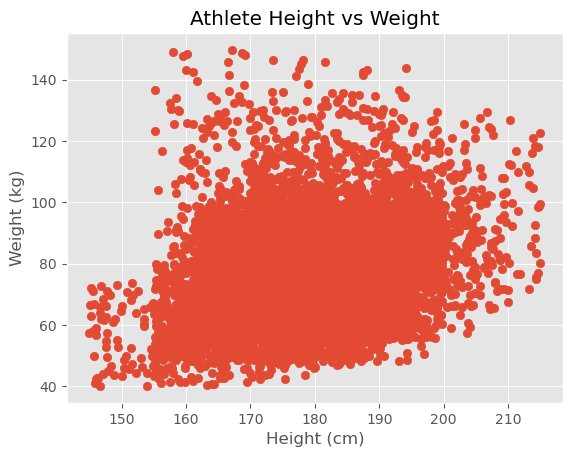

In [7]:
plt.figure()

plt.scatter(df["height_cm"], df["weight_kg"])

plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Athlete Height vs Weight")

plt.show()

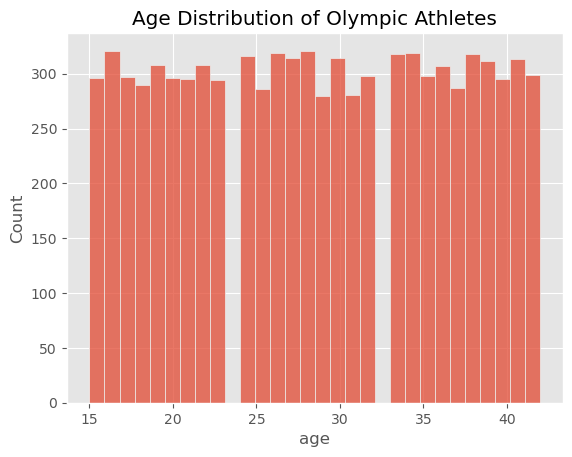

In [8]:
plt.figure()

sns.histplot(df["age"], bins=30)

plt.title("Age Distribution of Olympic Athletes")

plt.show()

In [9]:
country_stats = df.groupby("country_name").agg({
    "athlete_id":"count",
    "total_medals_won":"sum"
})

country_stats["medals_per_athlete"] = (
    country_stats["total_medals_won"] /
    country_stats["athlete_id"]
)

top_efficiency = country_stats.sort_values(
    "medals_per_athlete",
    ascending=False
).head(10)

top_efficiency

,athlete_id,total_medals_won,medals_per_athlete
country_name,,,
Nigeria,80,378,4.725000
Norway,179,808,4.513966
Switzerland,223,1004,4.502242
Jamaica,96,431,4.489583
Venezuela,101,450,4.455446
Malaysia,101,449,4.445545
Ethiopia,95,422,4.442105
Singapore,108,479,4.435185
Australia,232,1027,4.426724


In [10]:
df["medal_flag"] = df["medal"].apply(
    lambda x: 0 if x == "No Medal" else 1
)

In [11]:
features = [
"age",
"height_cm",
"weight_kg",
"total_olympics_attended"
]

data = df.dropna()

X = data[features]

y = data["medal_flag"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [13]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.7541176470588236
              precision    recall  f1-score   support

           0       0.78      0.96      0.86      1322
           1       0.21      0.04      0.07       378

    accuracy                           0.75      1700
   macro avg       0.50      0.50      0.46      1700
weighted avg       0.65      0.75      0.68      1700



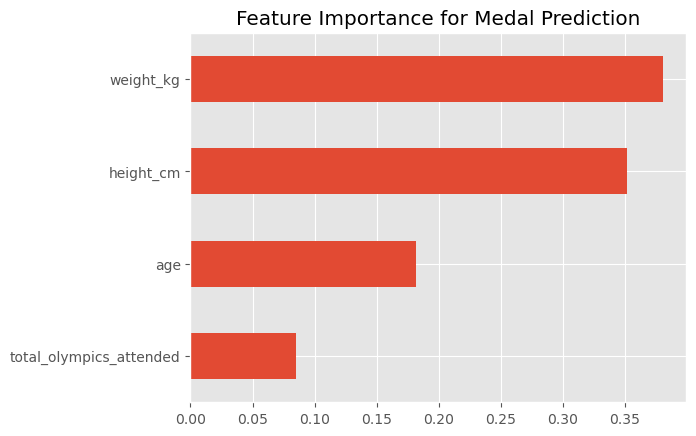

In [15]:
importance = pd.Series(
model.feature_importances_,
index=features
)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance for Medal Prediction")

plt.show()

In [16]:
print("Total Athletes:", df["athlete_id"].nunique())

print("Total Countries:", df["country_name"].nunique())

print("Olympic Years Covered:", df["year"].min(), "-", df["year"].max())

Total Athletes: 8500
Total Countries: 61
Olympic Years Covered: 1896 - 2024
